In [1]:
import traceback
from src.equation_discovery.config_equations_for_each_dataset import ConfigEquationDiscovery
from src.equation_discovery.evaluate_equation import test_equation, map_equation_to_syntax_tree, evaluate_equation
from src.analyse_equations.analyse_equations import fit_and_evaluate, proposed_equation_to_df
from src.analyse_equations.add_information_to_equations import add_propagate_error, add_units, add_performance_per_system, add_proposed_equations
from src.analyse_equations.utils import save_proposed_equation, get_train_test_files, load_proposed_equations
from src.analyse_equations.plot_error_per_system import plot_error_per_system
from src.analyse_equations.plot_histogram_for_features import histogram_for_features
from src.analyse_equations.plot_abs_difference_between_equation import abs_difference_between_equation
from src.preprocess_data.preprocess_data import prepare_dataset, split_train_test, get_unit_dict, split_train_test_sajjad
from src.analyse_equations.config_analyse_equations import ConfigPlotBestEquation
from src.preprocess_data.config_load_dataset import ConfigLoadData
from src.SyntaxTree.src.syntax_tree.config_syntax_tree import ConfigSyntaxTree
from src.utils.config_hyperparameter import ConfigHyperparameter
import pandas as pd

# Configs

In [2]:
parser =ConfigHyperparameter.arguments_parser()
parser= ConfigLoadData.arguments_parser(parser)
parser = ConfigEquationDiscovery.arguments_parser(parser)
parser = ConfigPlotBestEquation.arguments_parser(parser)
parser = ConfigSyntaxTree.arguments_parser(parser)
args = parser.parse_args()
args.save_path = args.ROOT_DIR /f'results/{args.save_set_folder}/equation_set_{args.equation_set_id}.json'
args.unit_dict = get_unit_dict(args)
args.unit_dict['y'] = args.unit_dict[args.target]
args.unit_dimension = 5
args.features= ['drop_length', 'adv', 'rec','avg_vel', 'width']
measurement_error_dic = {
    'drop_length': 0.5,
    'adv': 0.5,
    'rec': 0.5,
    'avg_vel': 0.5,
    'width': 0.5
}

# Results to load

In [3]:
proposed_equations = load_proposed_equations(args)
add_proposed_equations(args, proposed_equations)

# Dataset to load 

In [4]:
files_test, files_train = get_train_test_files(args, proposed_equations)
filtered_dfs_train = prepare_dataset(args, files_train)
filtered_dfs_test = prepare_dataset(args, files_test)

# Calculate Error over all data and per system 

In [5]:
equation_list = list(proposed_equations.keys())
for equation in equation_list:
    try:
        tree = fit_and_evaluate(args, equation, filtered_dfs_test, filtered_dfs_train, proposed_equations)
        add_performance_per_system(args, equation, filtered_dfs_test, proposed_equations, tree)
        add_units(args, equation, filtered_dfs_train, proposed_equations, tree)
        add_propagate_error(args, equation, filtered_dfs_test, measurement_error_dic, proposed_equations, tree)

    except Exception as e:
        del proposed_equations[equation]
        print(traceback.format_exc())
        print(e)
print('end')

Traceback (most recent call last):
  File "/tmp/ipykernel_8055/4107877036.py", line 6, in <module>
    add_units(args, equation, filtered_dfs_train, proposed_equations, tree)
  File "/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/analyse_equations/analyse_equations.py", line 243, in add_units
    changed = tree.start_node.parent_node.math_class.propagate_units(
  File "/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/SyntaxTree/src/equation_classes/math_class/y.py", line 53, in propagate_units
    changed |= self.node.list_children[0].math_class.propagate_units(call_node_id=self.node.node_id, dataset=dataset, kwargs=kwargs, changed=changed)
  File "/home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/src/SyntaxTree/src/equation_classes/math_class/multiplication.py", line 101, in propagate_units
    changed |= self.node.list_children[0].math_class.propagate_units(call_node_id=self.node.node_id, dataset=dataset, kwargs=kwargs, changed=chang

# Save proposed equation 

In [6]:
save_proposed_equation(args, files_test, files_train, proposed_equations)

Proposed Equations are saved to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Sajjad_Smoothed/equation_set_3_June.json


# Equations sorted after validation error 

In [7]:
num_variables = 1
pd.options.display.float_format = '${:.2e}'.format
df = proposed_equation_to_df(proposed_equations, num_variables)
df

,equation,infix,test all error,train all error,std
0,/ * c - adv rec drop_length,( ( c_0 * ( ( adv ) - ( rec ) ) ) / ( d...,$4.05e-10,$4.43e-10,$1.33e-02
1,/ * adv * c - adv rec drop_length,( ( ( adv ) * ( c_0 * ( ( adv ) - ( rec )...,$4.66e-10,$5.14e-10,$1.31e-02
2,* * c - adv rec exp sin rec,( ( c_0 * ( ( adv ) - ( rec ) ) ) * exp...,$3.59e-10,$4.07e-10,$2.32e-04
3,* c sin - adv rec,( c_0 * sin ( ( ( adv ) - ( rec ) ) ) ),$3.28e-10,$3.78e-10,$2.23e-04
4,+ c * friction_coef * width * viscosity avg_vel,( c_0 + ( ( friction_coef ) * ( ( width ) ...,$2.03e-10,$2.41e-10,$1.12e-02
...,...,...,...,...,...
323,* c * - adv rec / sin rec drop_length,( c_0 * ( ( ( adv ) - ( rec ) ) * ( sin ...,$4.37e-10,$4.61e-10,$1.33e-02
324,* c ** cos / rec adv 3,( c_0 * cos (( ( rec ) / ( adv ) ) ) ...,$2.21e-10,$3.00e-10,$2.20e-04
325,* c * adv / 1 * rec ** adv 2,( c_0 * ( ( adv ) * ( ( 1 ) / ( ( rec ) ...,$4.17e-10,$4.01e-10,$5.78e-05
326,* c / 1 * rec ** ** adv 2 2,( c_0 * ( ( 1 ) / ( ( rec ) * ( adv )...,$5.27e-10,$4.64e-10,$1.56e-04


# Analyse one equation 

In [8]:
index = 24
equation=proposed_equations[df.iloc[index].loc['equation']]
equation_prefix = df.iloc[index].loc['equation']
tree = map_equation_to_syntax_tree(args, equation_prefix, infix=False, catch_exceptions=False)
for id , units in equation['units'].items():
    i = float(id.split('_')[0])
tree.constants_in_tree = proposed_equations[equation_prefix]['train_all']['constants']
add_units(args, equation_prefix, filtered_dfs_train, proposed_equations, tree)
print(tree.rearrange_equation_infix_notation())
tree.print()

('y', '( c_0 * ( (  ( drop_length )  * (  ( drop_length )  /  ( y_center )  )  )  *  ( drop_length )  )  ) ')
d: 0  id: 0.0   *	 [np.float64(1.0), np.float64(-2.0), np.float64(1.0), np.float64(0.0), np.float64(0.0)]
d: 1  id: 1.0   	c_0	 [np.float64(-1.0), np.float64(-2.0), np.float64(1.0), np.float64(0.0), np.float64(0.0)]
d: 1  id: 512.0 	*	 [np.float64(2.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
d: 2  id: 513.0 		*	 [np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
d: 3  id: 514.0 			drop_length	 [1. 0. 0. 0. 0.]
d: 3  id: 641.0 			/	 [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
d: 4  id: 642.0 				drop_length	 [1. 0. 0. 0. 0.]
d: 4  id: 705.0 				y_center	 [1. 0. 0. 0. 0.]
d: 2  id: 768.0 		drop_length	 [1. 0. 0. 0. 0.]


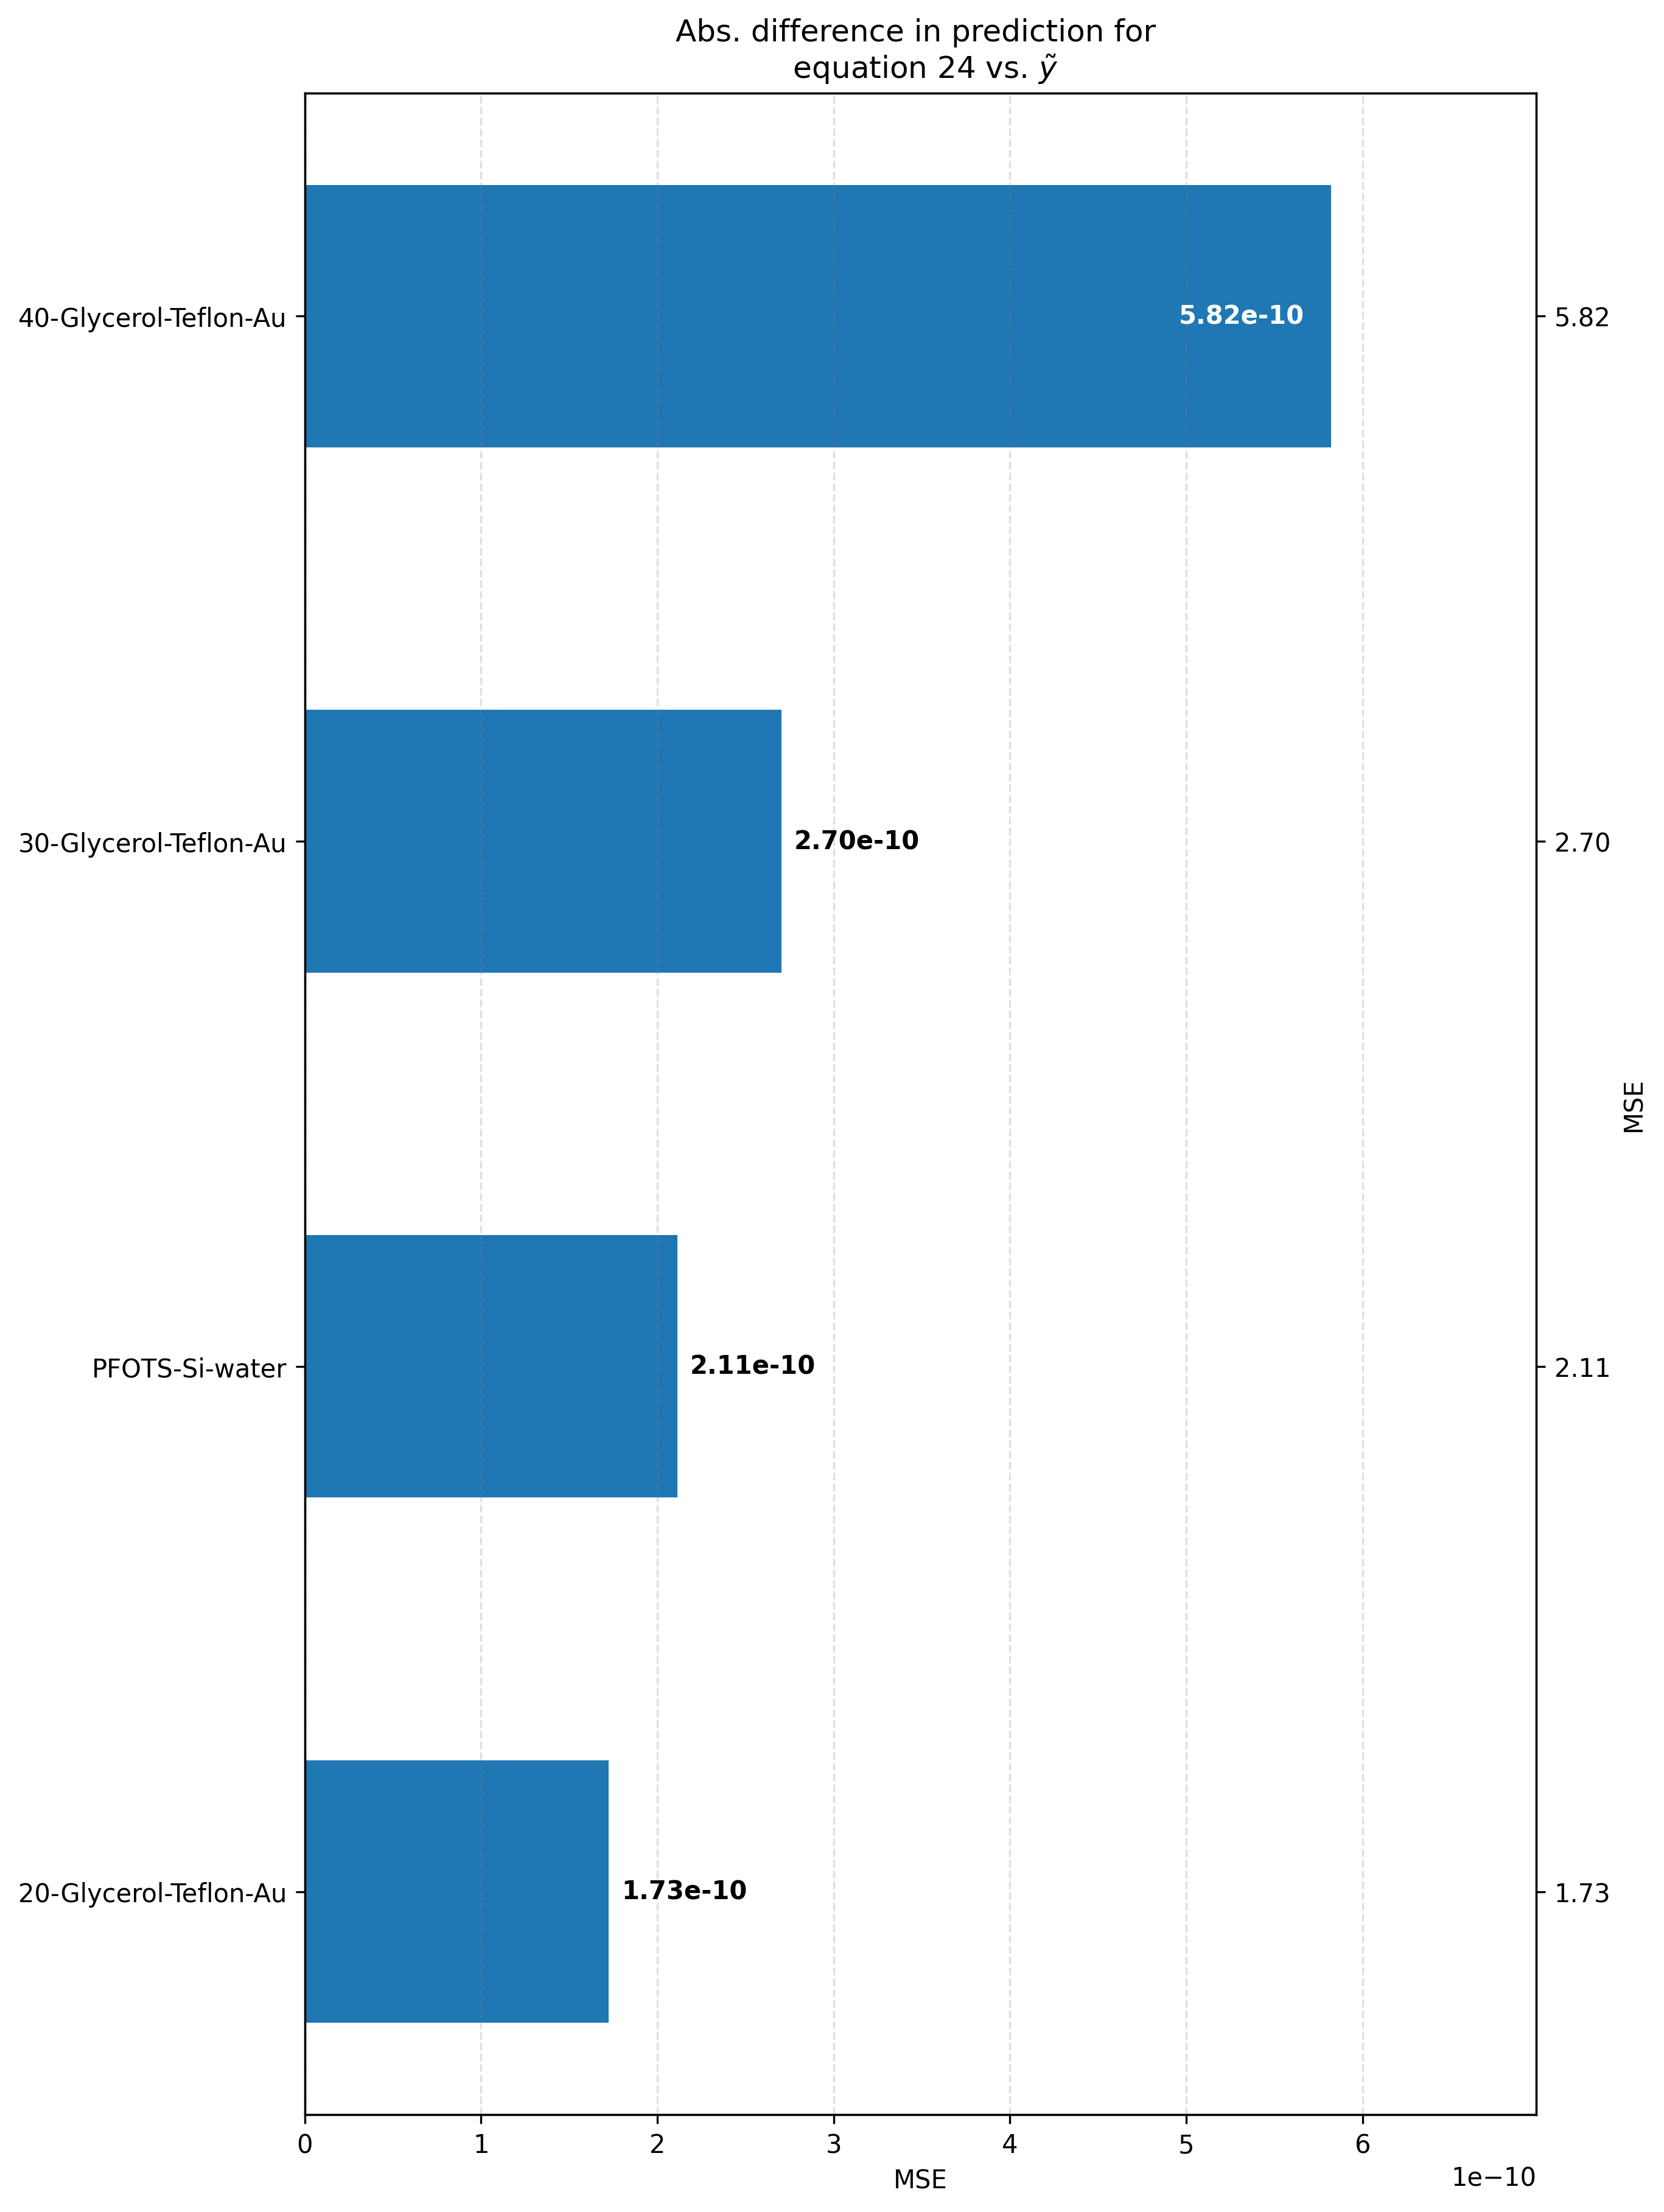

In [9]:
plot_error_per_system(args,df, index, proposed_equations) 

# Analyse Feature 

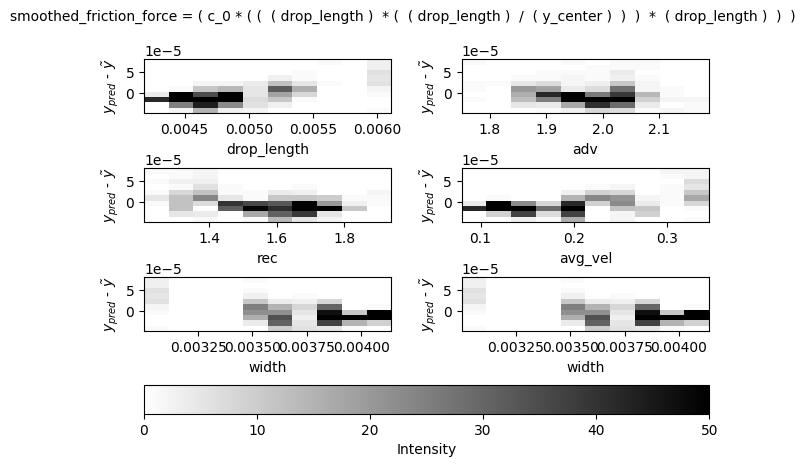

In [10]:
from src.analyse_equations.analyse_equations import  histogram_for_features
histogram_for_features(args, filtered_dfs_test, tree)

# Compare two equations

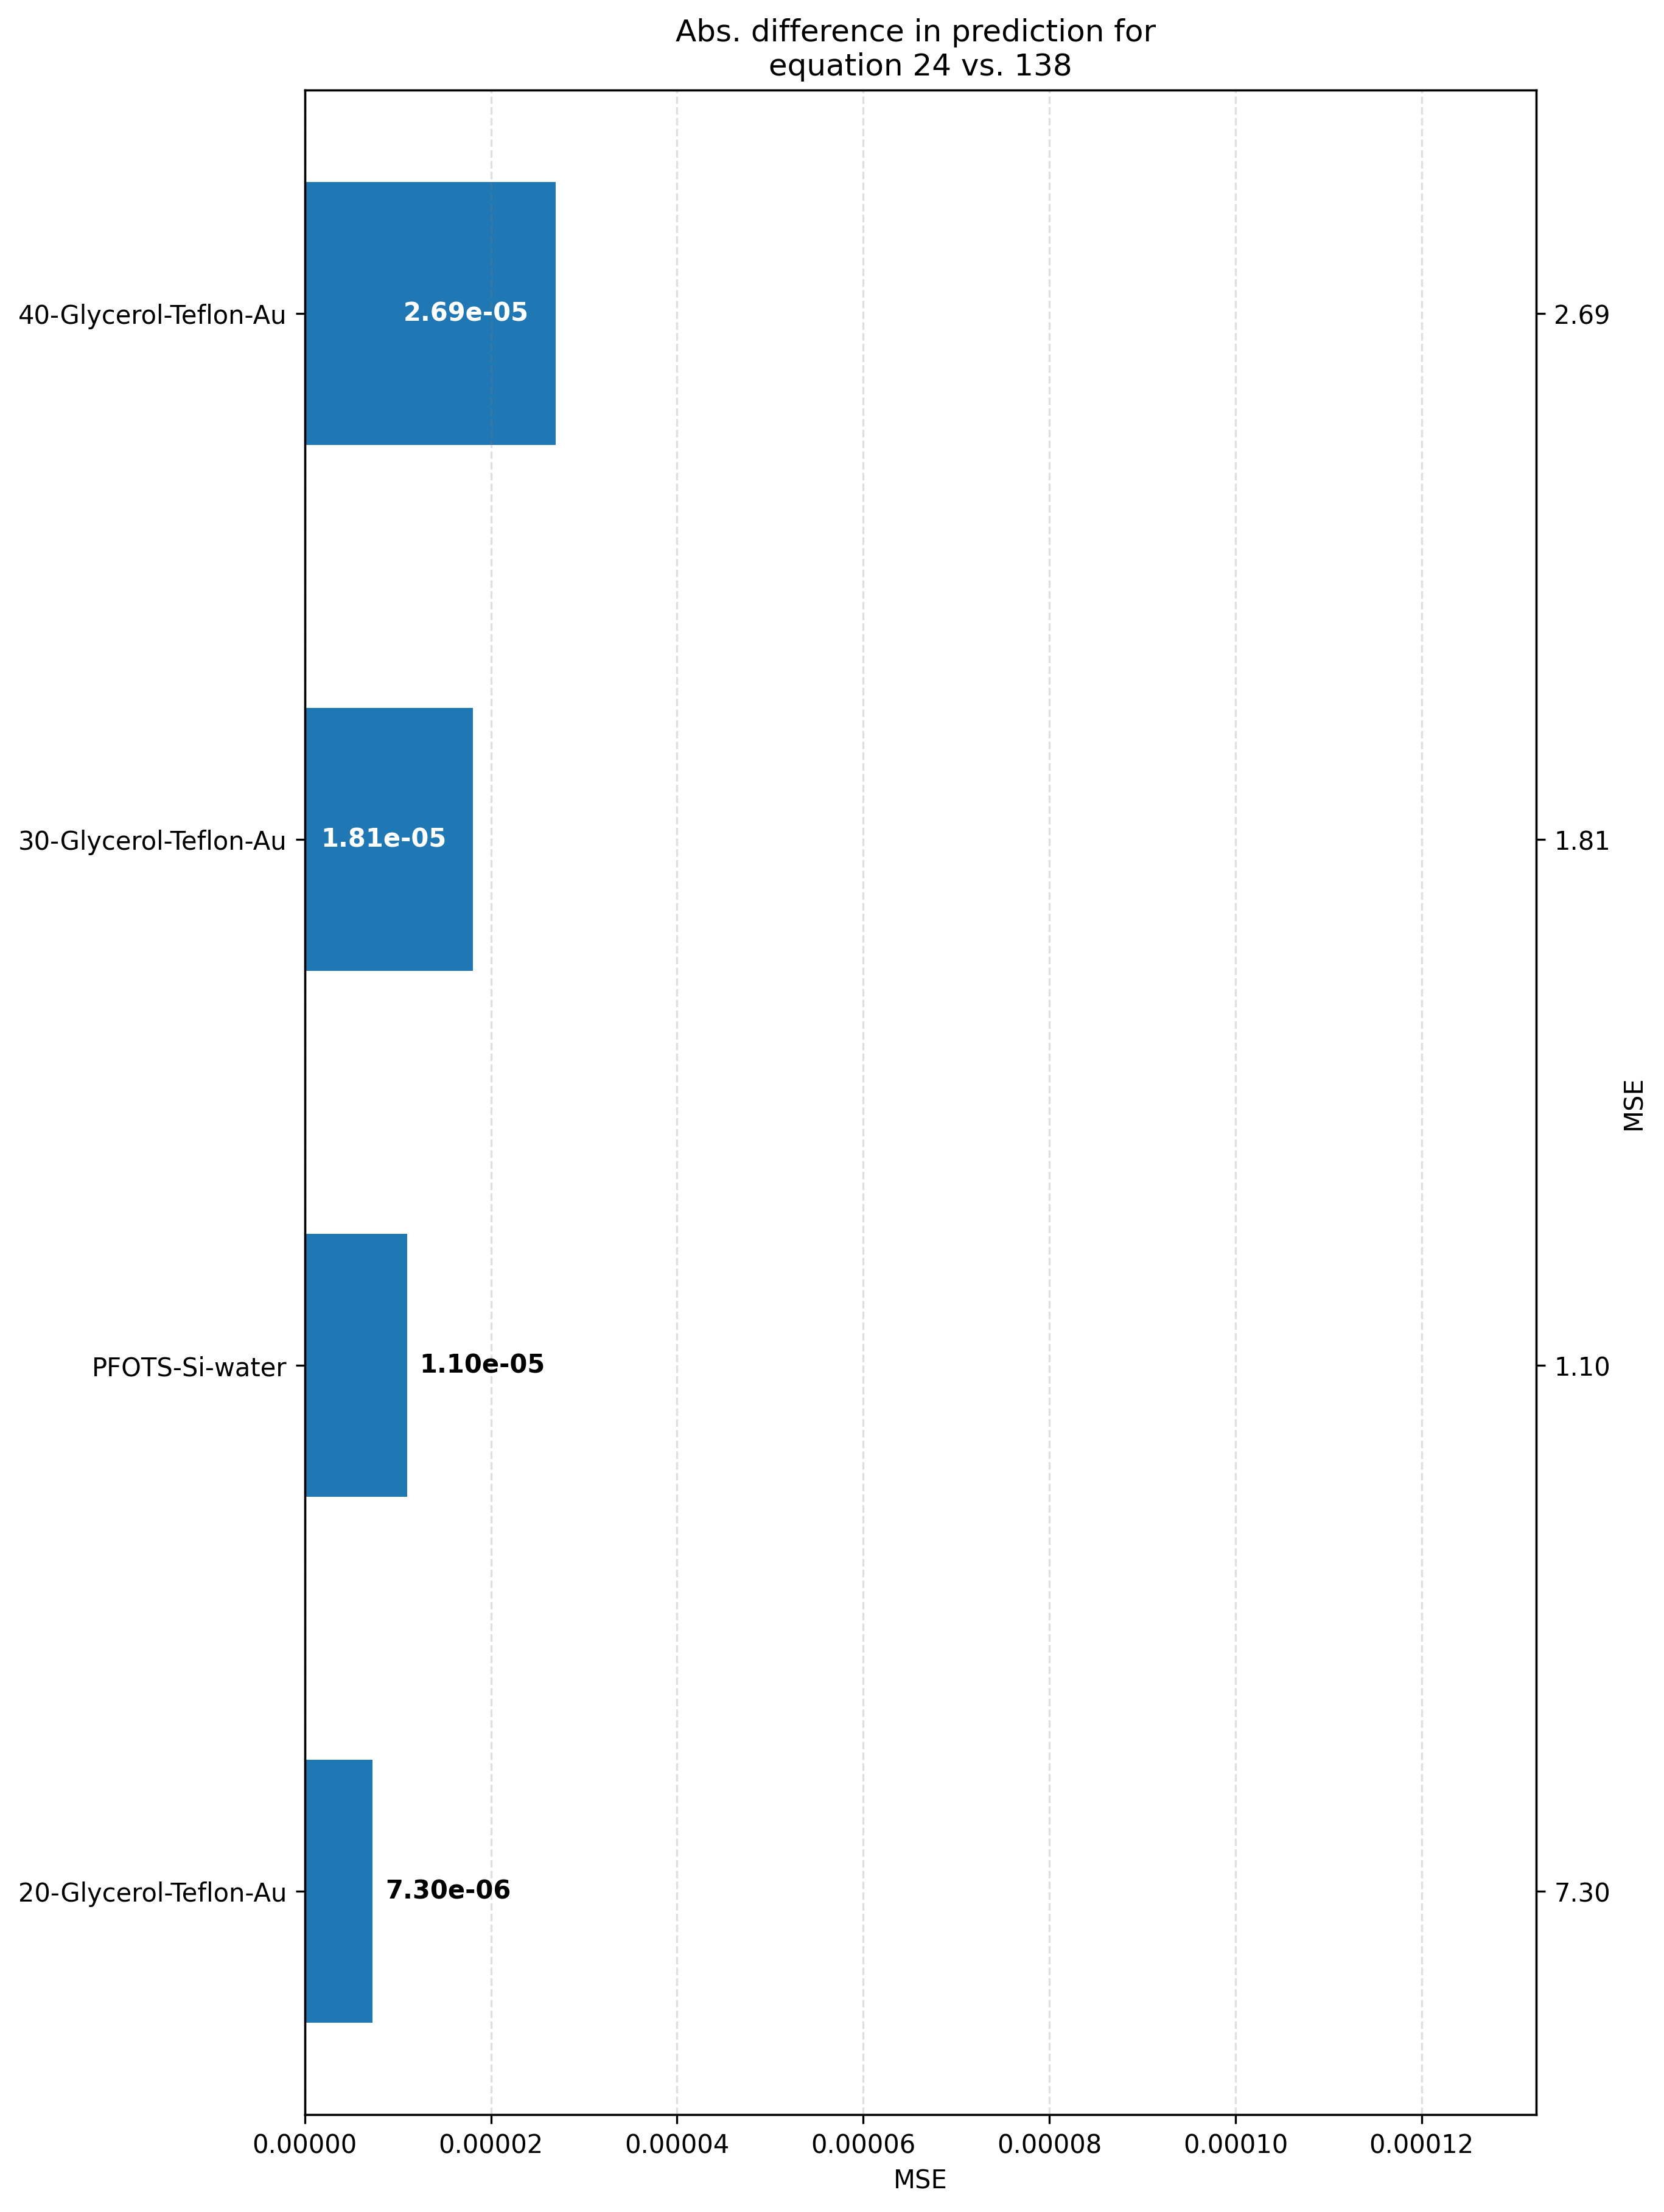

In [11]:
index_0 = 24
index_1 = 138
abs_difference_between_equation(args, proposed_equations, df, filtered_dfs_test, index_0, index_1)
